In [17]:
"""
01_data_exploration.ipynb
=========================
Copy each section between # %% markers into separate notebook cells.
Update PROCESSED_DIR to your actual path.
"""

'\n01_data_exploration.ipynb\n=========================\nCopy each section between # %% markers into separate notebook cells.\nUpdate PROCESSED_DIR to your actual path.\n'

# 01 - Data Exploration

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict, Counter
from pathlib import Path

# ─── UPDATE THIS PATH ───
PROCESSED_DIR = r"C:\Users\rajcr\Desktop\Study\MTech\Courses\CV\Project\Dataset\leaked_data_split"
# ─────────────────────────

CLASS_NAMES = {0: "bike", 1: "helmet", 2: "no-helmet", 3: "number-plate"}
COLORS = {
    "bike": "#2196F3",
    "helmet": "#4CAF50",
    "no-helmet": "#F44336",
    "number-plate": "#FF9800",
}

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

SAVE_DIR = os.path.join(PROCESSED_DIR, "exploration_plots")
os.makedirs(SAVE_DIR, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(os.path.join(SAVE_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")
    print(f"Saved: {name}.png")

In [8]:
def load_all_annotations(split_dir):
    """Load all labels from a split directory."""
    labels_dir = os.path.join(split_dir, "labels")
    images_dir = os.path.join(split_dir, "images")

    data = []
    if not os.path.isdir(labels_dir):
        return data

    for label_file in sorted(os.listdir(labels_dir)):
        if not label_file.endswith(".txt"):
            continue

        img_name = os.path.splitext(label_file)[0] + ".jpg"
        img_path = os.path.join(images_dir, img_name)

        annotations = []
        with open(os.path.join(labels_dir, label_file)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    annotations.append({"class_id": cls_id, "cx": cx, "cy": cy, "w": w, "h": h})

        data.append({
            "image": img_name,
            "image_path": img_path,
            "annotations": annotations,
        })

    return data


all_data = {}
for split in ["train", "val", "test"]:
    split_dir = os.path.join(PROCESSED_DIR, split)
    if os.path.isdir(split_dir):
        all_data[split] = load_all_annotations(split_dir)
        print(f"{split}: {len(all_data[split])} images")

train: 5216 images
val: 652 images
test: 653 images


In [9]:
# Check if same-prefix frames appear in multiple splits (data leakage)
import os
from collections import defaultdict

splits_dir = PROCESSED_DIR 
prefix_to_splits = defaultdict(set)

for split in ["train", "val", "test"]:
    img_dir = os.path.join(splits_dir, split, "images")
    for f in os.listdir(img_dir):
        # Extract prefix (everything before first digit)
        prefix = ""
        for i, ch in enumerate(f):
            if ch.isdigit() and i > 0:
                prefix = f[:i].rstrip("_-")
                break
        if prefix:
            prefix_to_splits[prefix].add(split)

# Show prefixes that appear in multiple splits
print("LEAKED PREFIXES (appear in multiple splits):")
for prefix, splits in sorted(prefix_to_splits.items()):
    if len(splits) > 1:
        print(f"  {prefix}: {splits}")

LEAKED PREFIXES (appear in multiple splits):
  0: {'val', 'test', 'train'}
  1: {'val', 'test', 'train'}
  2: {'val', 'test', 'train'}
  3: {'val', 'test', 'train'}
  4: {'val', 'test', 'train'}
  4c: {'val', 'test', 'train'}
  5: {'val', 'test', 'train'}
  6: {'val', 'test', 'train'}
  7: {'val', 'test', 'train'}
  8: {'val', 'test', 'train'}
  9: {'val', 'test', 'train'}
  BikesHelmets: {'val', 'test', 'train'}
  IMG: {'val', 'test', 'train'}
  Mask-detector: {'test', 'train'}
  PXL: {'test', 'train'}
  Untitled-Made-with-FlexClip: {'val', 'test', 'train'}
  face-detection_mp: {'val', 'train'}
  frame: {'val', 'test', 'train'}
  frame-Data: {'val', 'test', 'train'}
  gravitate-faces_mp: {'val', 'train'}
  hdetect: {'val', 'test', 'train'}
  he: {'val', 'test', 'train'}
  helmetimage: {'val', 'test', 'train'}
  image: {'val', 'test', 'train'}
  images: {'test', 'train'}
  mask-wearing: {'val', 'test', 'train'}
  no-mask_mov: {'val', 'train'}
  p: {'val', 'train'}
  pexels-photo: {'tes

Saved: 01_class_distribution.png


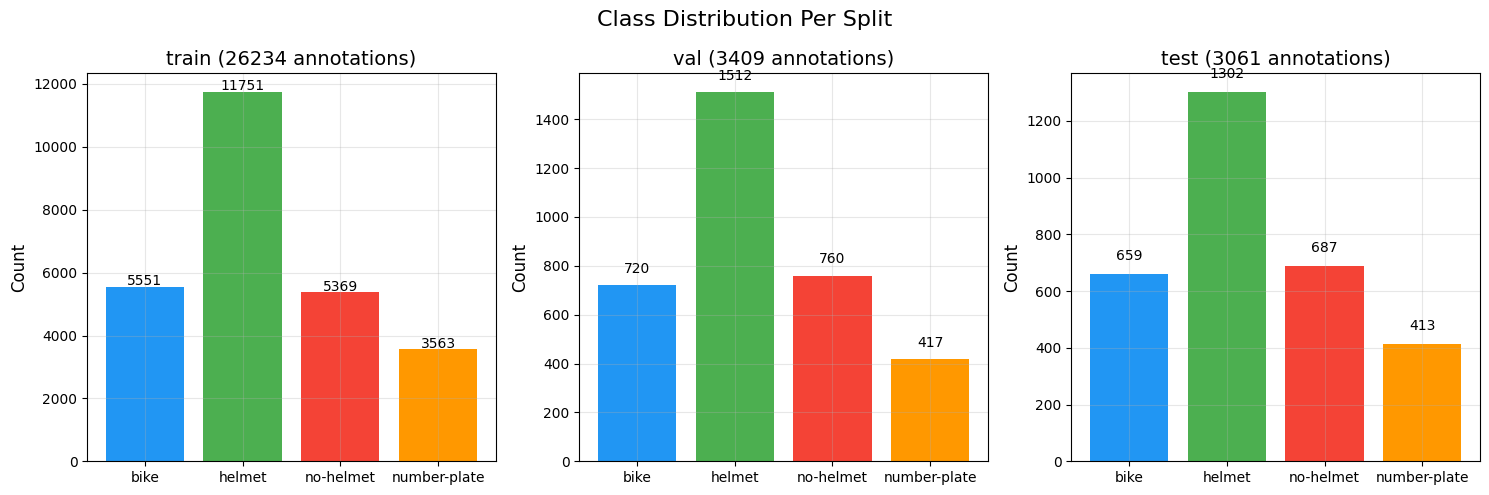

In [11]:
fig, axes = plt.subplots(1, len(all_data), figsize=(5 * len(all_data), 5))
if len(all_data) == 1:
    axes = [axes]

for ax, (split, data) in zip(axes, all_data.items()):
    counts = defaultdict(int)
    for item in data:
        for ann in item["annotations"]:
            counts[ann["class_id"]] += 1

    classes = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
    values = [counts.get(i, 0) for i in sorted(CLASS_NAMES.keys())]
    colors = [COLORS[CLASS_NAMES[i]] for i in sorted(CLASS_NAMES.keys())]

    bars = ax.bar(classes, values, color=colors)
    ax.set_title(f"{split} ({sum(values)} annotations)")
    ax.set_ylabel("Count")

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                str(val), ha="center", fontsize=10)

fig.suptitle("Class Distribution Per Split", fontsize=16)
fig.tight_layout()
save_fig(fig, "01_class_distribution")
plt.show()

Saved: 02_class_proportions.png


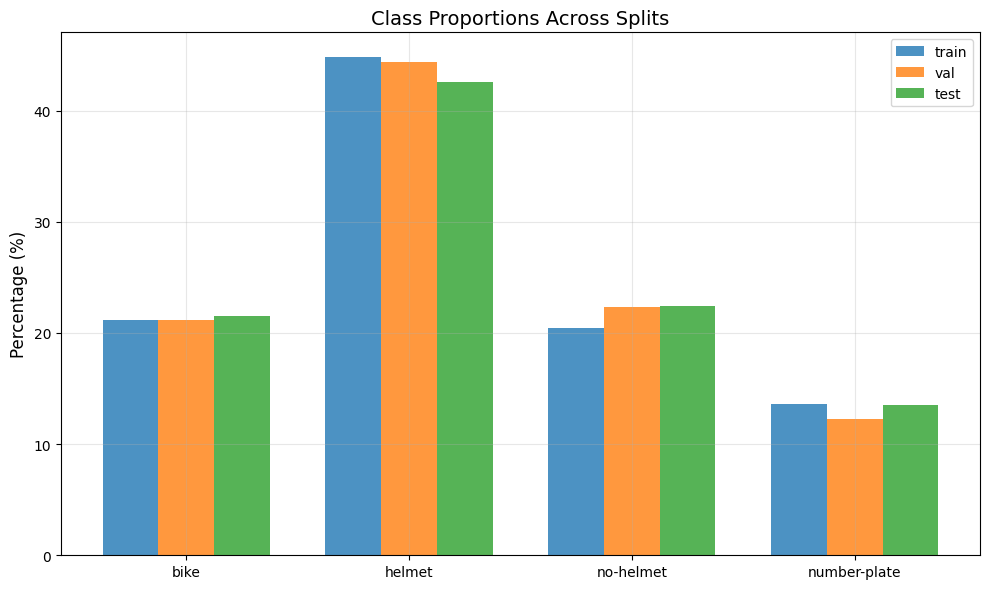

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

splits = list(all_data.keys())
x = np.arange(len(CLASS_NAMES))
width = 0.25

for i, split in enumerate(splits):
    counts = defaultdict(int)
    for item in all_data[split]:
        for ann in item["annotations"]:
            counts[ann["class_id"]] += 1
    total = sum(counts.values())
    proportions = [counts.get(j, 0) / max(total, 1) * 100 for j in sorted(CLASS_NAMES.keys())]
    ax.bar(x + i * width, proportions, width, label=split, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels([CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())])
ax.set_ylabel("Percentage (%)")
ax.set_title("Class Proportions Across Splits")
ax.legend()
fig.tight_layout()
save_fig(fig, "02_class_proportions")
plt.show()

Saved: 03_bbox_size_distribution.png


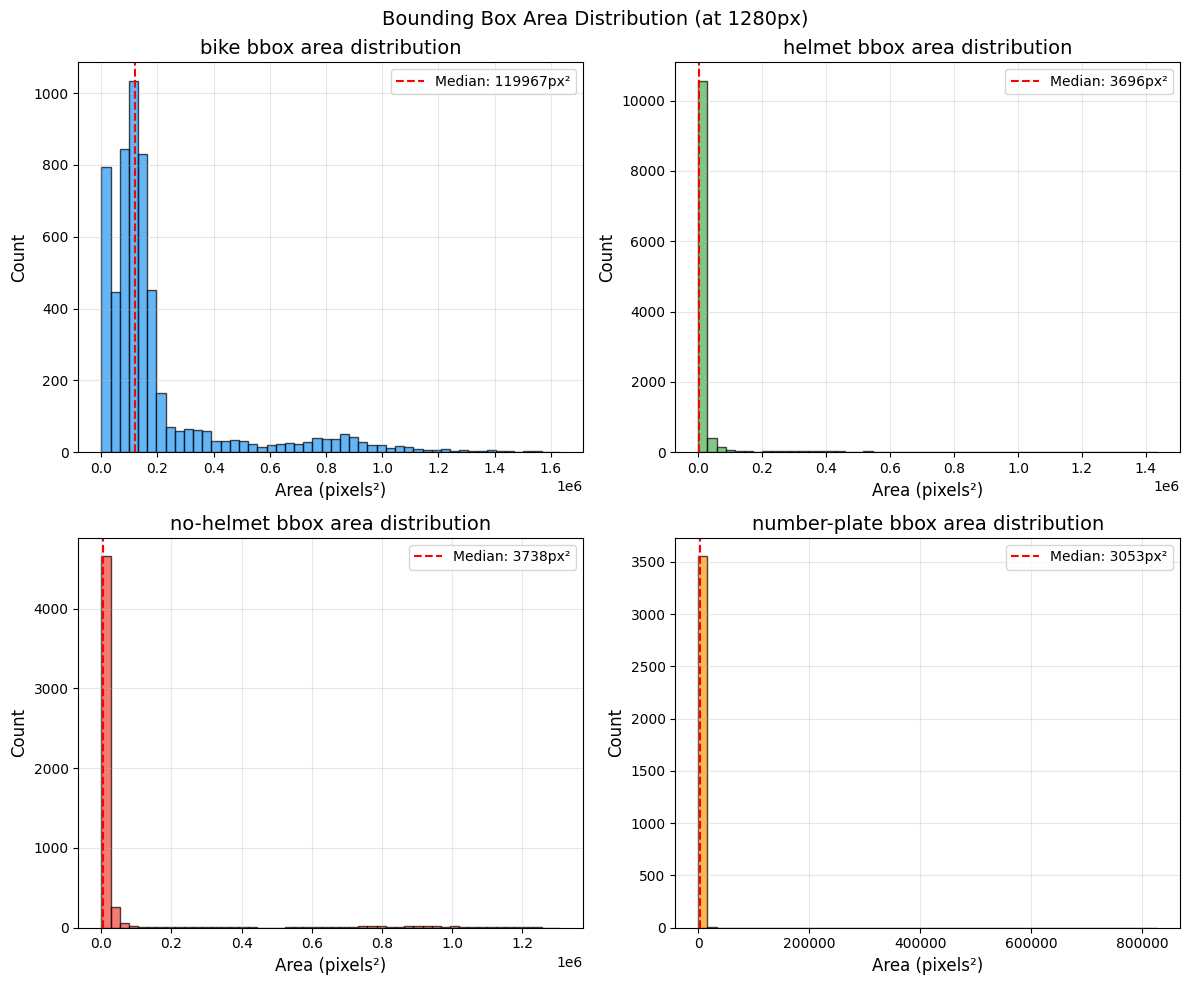

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Use train split for bbox analysis
train_data = all_data.get("train", [])
bbox_sizes = defaultdict(list)

for item in train_data:
    for ann in item["annotations"]:
        # Approximate pixel size assuming 1280px input
        w_px = ann["w"] * 1280
        h_px = ann["h"] * 1280
        area = w_px * h_px
        bbox_sizes[ann["class_id"]].append({"w": w_px, "h": h_px, "area": area})

for idx, cls_id in enumerate(sorted(CLASS_NAMES.keys())):
    ax = axes[idx // 2][idx % 2]
    cls_name = CLASS_NAMES[cls_id]

    if bbox_sizes[cls_id]:
        areas = [b["area"] for b in bbox_sizes[cls_id]]
        ax.hist(areas, bins=50, color=COLORS[cls_name], alpha=0.7, edgecolor="black")
        ax.axvline(np.median(areas), color="red", linestyle="--",
                   label=f"Median: {np.median(areas):.0f}px²")
        ax.set_title(f"{cls_name} bbox area distribution")
        ax.set_xlabel("Area (pixels²)")
        ax.set_ylabel("Count")
        ax.legend()
    else:
        ax.set_title(f"{cls_name} — no annotations")

fig.suptitle("Bounding Box Area Distribution (at 1280px)", fontsize=14)
fig.tight_layout()
save_fig(fig, "03_bbox_size_distribution")
plt.show()

Saved: 04_bbox_width_vs_height.png


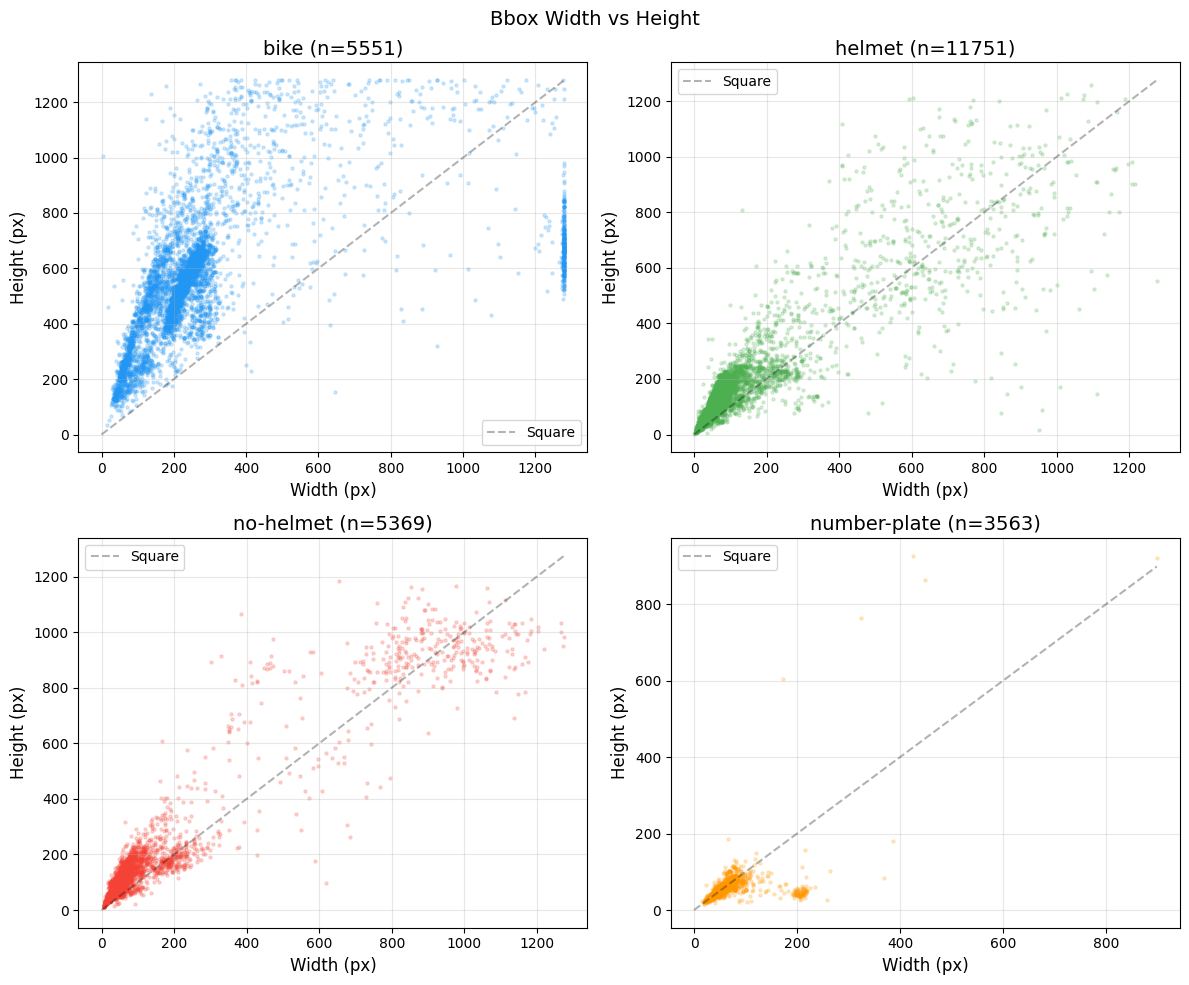

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, cls_id in enumerate(sorted(CLASS_NAMES.keys())):
    ax = axes[idx // 2][idx % 2]
    cls_name = CLASS_NAMES[cls_id]

    if bbox_sizes[cls_id]:
        widths = [b["w"] for b in bbox_sizes[cls_id]]
        heights = [b["h"] for b in bbox_sizes[cls_id]]
        ax.scatter(widths, heights, alpha=0.2, s=5, color=COLORS[cls_name])
        ax.set_title(f"{cls_name} (n={len(widths)})")
        ax.set_xlabel("Width (px)")
        ax.set_ylabel("Height (px)")
        ax.plot([0, max(widths)], [0, max(widths)], "k--", alpha=0.3, label="Square")
        ax.legend()
    else:
        ax.set_title(f"{cls_name} — no data")

fig.suptitle("Bbox Width vs Height", fontsize=14)
fig.tight_layout()
save_fig(fig, "04_bbox_width_vs_height")
plt.show()

Saved: 05_objects_per_image.png


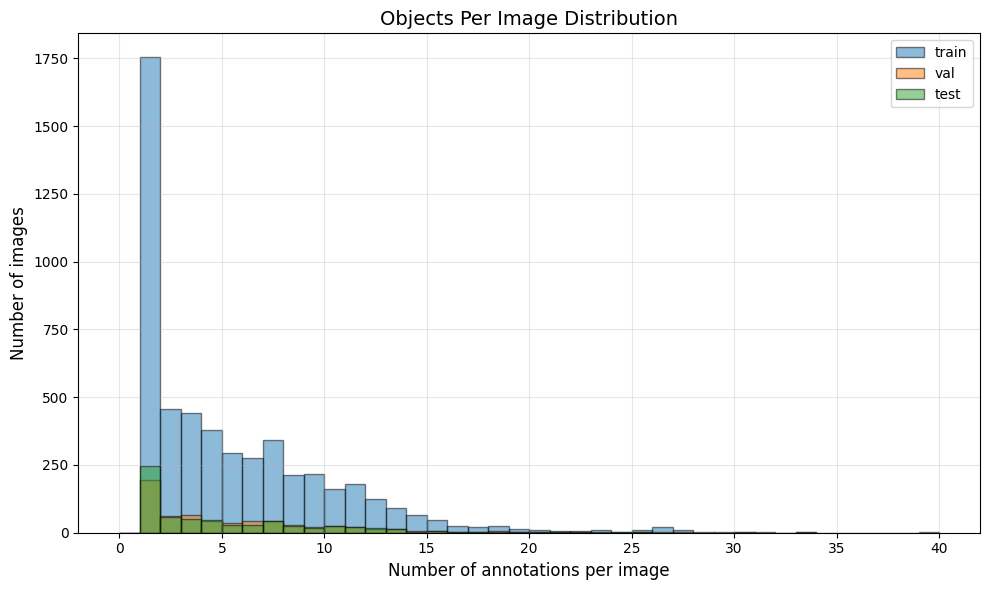

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

for split, data in all_data.items():
    obj_counts = [len(item["annotations"]) for item in data]
    ax.hist(obj_counts, bins=range(0, max(obj_counts) + 2), alpha=0.5, label=split, edgecolor="black")

ax.set_xlabel("Number of annotations per image")
ax.set_ylabel("Number of images")
ax.set_title("Objects Per Image Distribution")
ax.legend()
fig.tight_layout()
save_fig(fig, "05_objects_per_image")
plt.show()

Saved: 06_cooccurrence.png


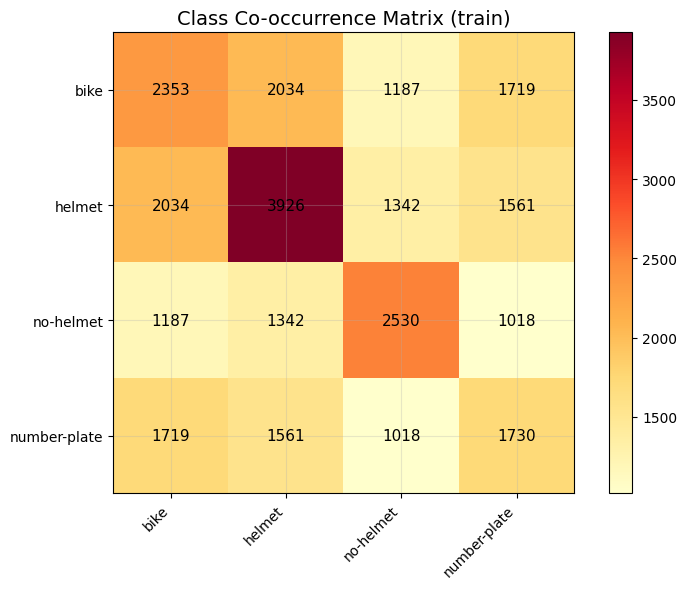

In [16]:
train_data = all_data.get("train", [])
n_classes = len(CLASS_NAMES)
cooccurrence = np.zeros((n_classes, n_classes), dtype=int)

for item in train_data:
    present_classes = set(ann["class_id"] for ann in item["annotations"])
    for c1 in present_classes:
        for c2 in present_classes:
            cooccurrence[c1][c2] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cooccurrence, cmap="YlOrRd")

class_labels = [CLASS_NAMES[i] for i in range(n_classes)]
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_yticklabels(class_labels)

for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, str(cooccurrence[i][j]), ha="center", va="center", fontsize=11)

fig.colorbar(im)
ax.set_title("Class Co-occurrence Matrix (train)")
fig.tight_layout()
save_fig(fig, "06_cooccurrence")
plt.show()

Saved: 07_violation_profiles.png


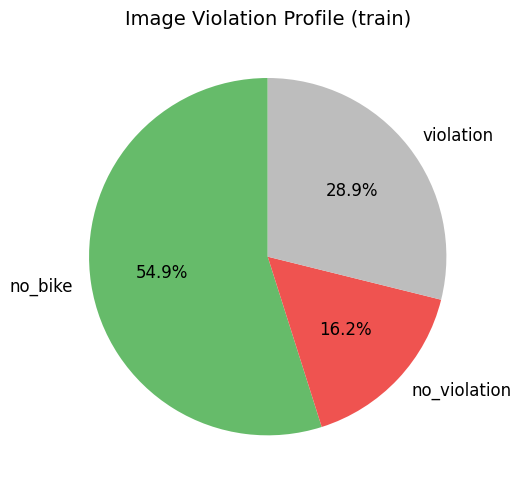

In [17]:
train_data = all_data.get("train", [])
violation_profiles = Counter()

for item in train_data:
    n_bikes = sum(1 for a in item["annotations"] if a["class_id"] == 0)
    n_helmets = sum(1 for a in item["annotations"] if a["class_id"] == 1)
    n_no_helmets = sum(1 for a in item["annotations"] if a["class_id"] == 2)
    n_plates = sum(1 for a in item["annotations"] if a["class_id"] == 3)

    has_violation = n_no_helmets > 0 or (n_helmets + n_no_helmets) > 2
    if n_bikes == 0:
        profile = "no_bike"
    elif has_violation:
        profile = "violation"
    else:
        profile = "no_violation"

    violation_profiles[profile] += 1

fig, ax = plt.subplots(figsize=(8, 5))
labels = list(violation_profiles.keys())
values = list(violation_profiles.values())
colors_pie = ["#66BB6A", "#EF5350", "#BDBDBD"]

ax.pie(values, labels=labels, autopct="%1.1f%%", colors=colors_pie[:len(labels)],
       startangle=90, textprops={"fontsize": 12})
ax.set_title("Image Violation Profile (train)")
fig.tight_layout()
save_fig(fig, "07_violation_profiles")
plt.show()

Saved: 08_sample_images.png


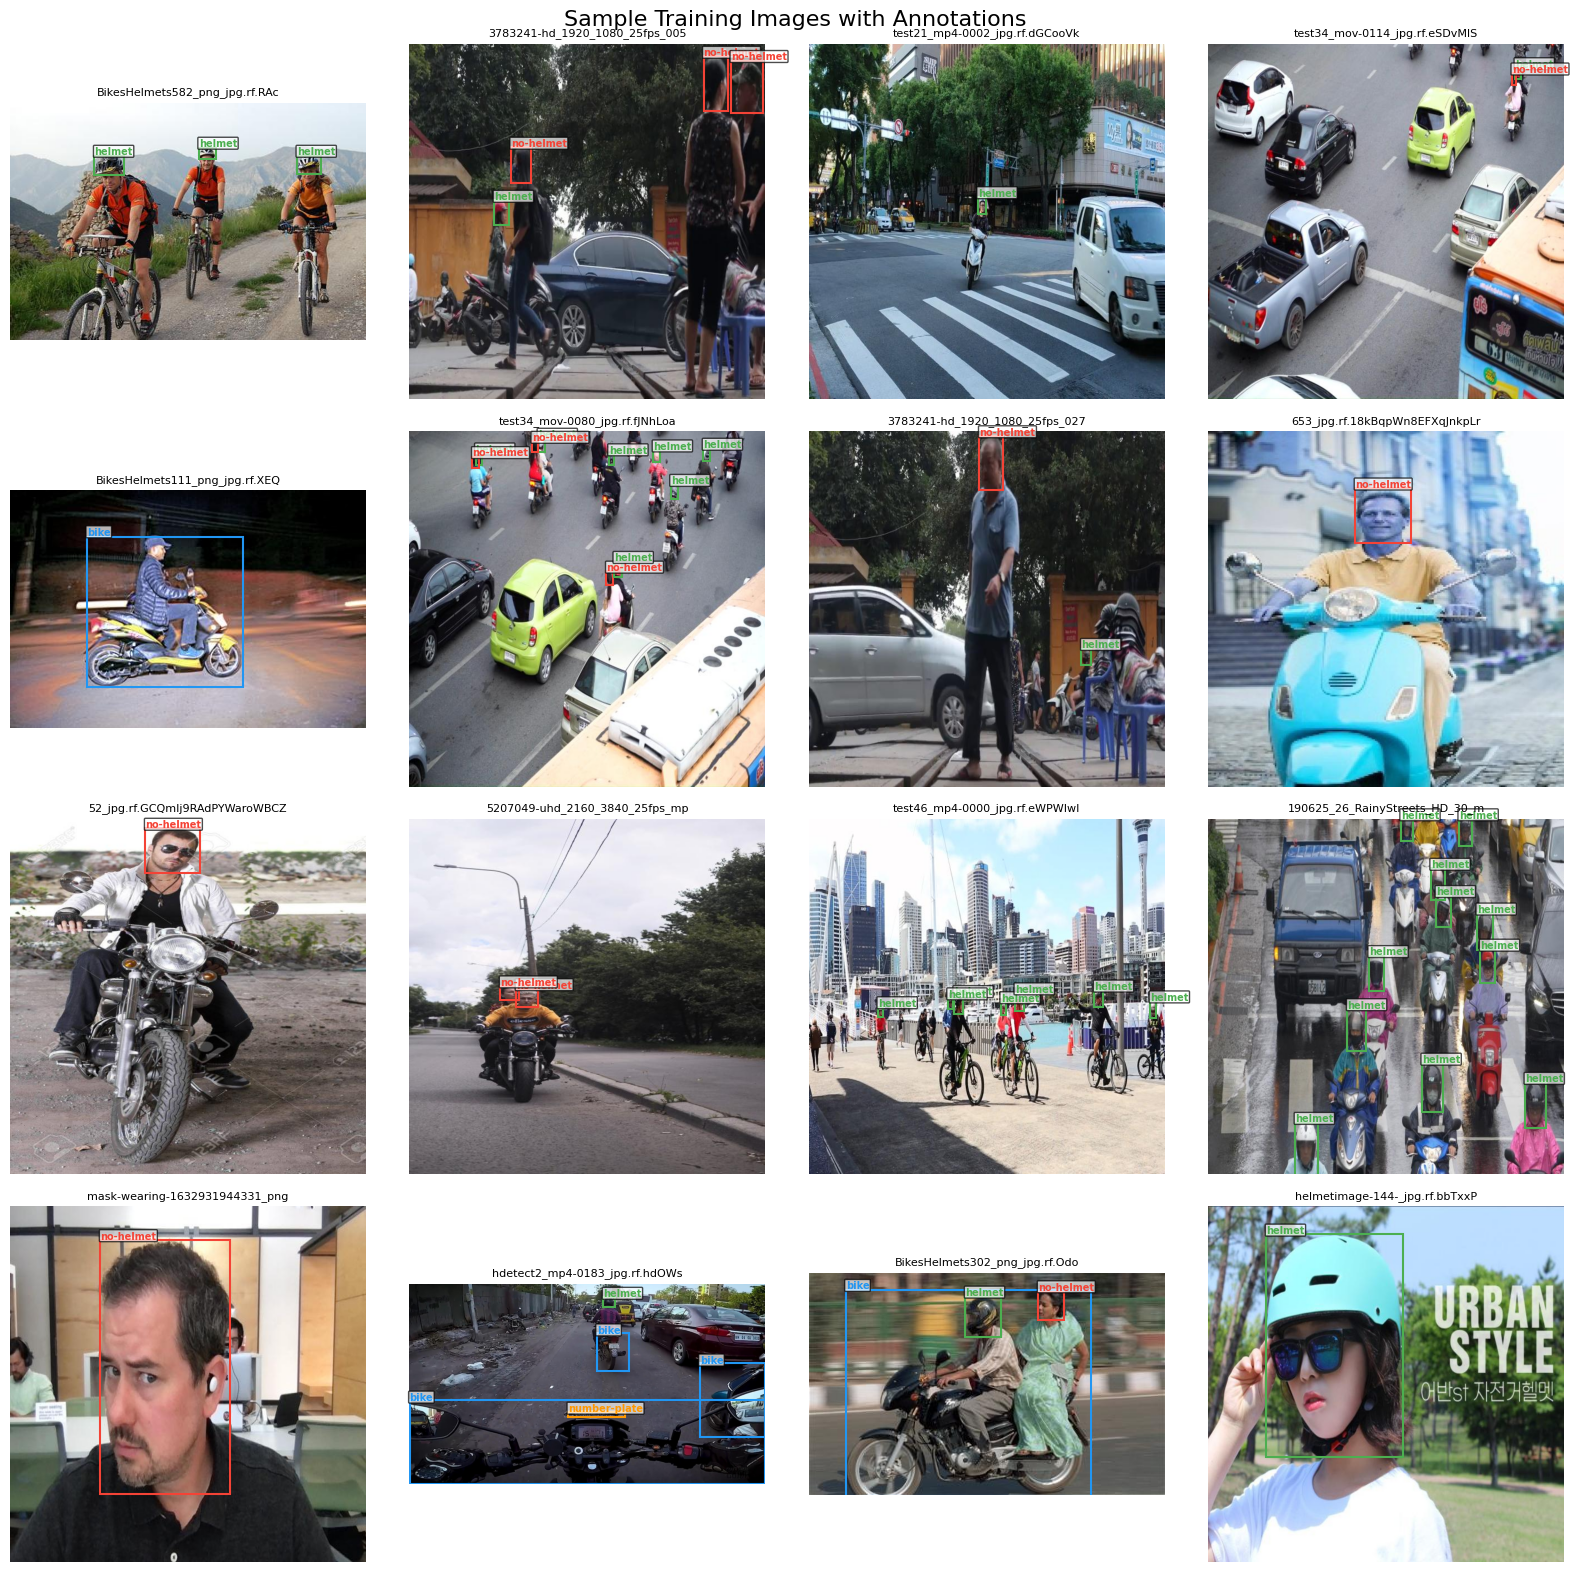

In [20]:
train_data = all_data.get("train", [])
# Pick 16 random images that have annotations
annotated = [d for d in train_data if len(d["annotations"]) > 0]
np.random.seed(42)
samples = np.random.choice(len(annotated), min(16, len(annotated)), replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
color_map = {0: (33, 150, 243), 1: (76, 175, 80), 2: (244, 67, 54), 3: (255, 152, 0)}

for idx, ax in enumerate(axes.flat):
    if idx >= len(samples):
        ax.axis("off")
        continue

    item = annotated[samples[idx]]
    img = cv2.imread(item["image_path"])
    if img is None:
        ax.axis("off")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img)

    for ann in item["annotations"]:
        cx, cy, bw, bh = ann["cx"] * w, ann["cy"] * h, ann["w"] * w, ann["h"] * h
        x1, y1 = cx - bw / 2, cy - bh / 2
        color_rgb = [c / 255 for c in color_map.get(ann["class_id"], (255, 255, 255))]
        rect = patches.Rectangle((x1, y1), bw, bh, linewidth=1.5,
                                  edgecolor=color_rgb, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, CLASS_NAMES[ann["class_id"]], fontsize=7,
                color=color_rgb, weight="bold",
                bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7))

    ax.set_title(item["image"][:30], fontsize=8)
    ax.axis("off")

fig.suptitle("Sample Training Images with Annotations", fontsize=16)
fig.tight_layout()
save_fig(fig, "08_sample_images")
plt.show()

In [19]:
print("=" * 60)
print("  DATASET SUMMARY")
print("=" * 60)

for split, data in all_data.items():
    counts = defaultdict(int)
    for item in data:
        for ann in item["annotations"]:
            counts[ann["class_id"]] += 1
    total = sum(counts.values())
    print(f"\n{split}: {len(data)} images, {total} annotations")
    for cls_id in sorted(CLASS_NAMES.keys()):
        c = counts.get(cls_id, 0)
        pct = c / max(total, 1) * 100
        print(f"  {CLASS_NAMES[cls_id]:15s}: {c:5d} ({pct:.1f}%)")

  DATASET SUMMARY

train: 5216 images, 26234 annotations
  bike           :  5551 (21.2%)
  helmet         : 11751 (44.8%)
  no-helmet      :  5369 (20.5%)
  number-plate   :  3563 (13.6%)

val: 652 images, 3409 annotations
  bike           :   720 (21.1%)
  helmet         :  1512 (44.4%)
  no-helmet      :   760 (22.3%)
  number-plate   :   417 (12.2%)

test: 653 images, 3061 annotations
  bike           :   659 (21.5%)
  helmet         :  1302 (42.5%)
  no-helmet      :   687 (22.4%)
  number-plate   :   413 (13.5%)
